In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

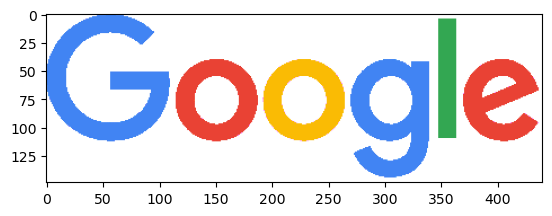

In [9]:
imgGoogle = cv2.imread("Google_2015_logo.svg.png")
imgGoogleRgb = cv2.cvtColor(imgGoogle, cv2.COLOR_BGR2RGB)
GoogleW = imgGoogleRgb.shape[0]
GoogleH = imgGoogleRgb.shape[1]
imgGoogleRgb = imgGoogleRgb - 1   #???????????????????????????????
plt.imshow(imgGoogleRgb)

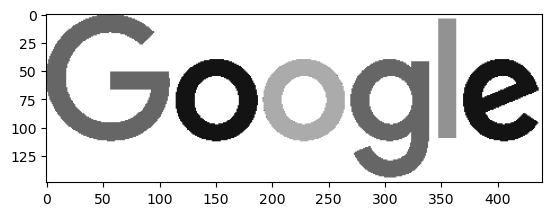

In [139]:
imgGoogleGray = imgGoogleRgb[:,:,1]
plt.imshow(imgGoogleGray, cmap='gray')

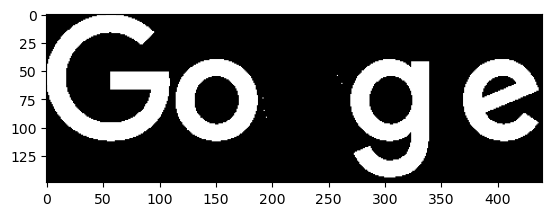

In [248]:
retval, imgGoogleMask1 = cv2.threshold(imgGoogleGray, 150, 255, cv2.THRESH_BINARY)
imgGoogleMaskInv1 = cv2.bitwise_not(imgGoogleMask1)
plt.imshow(imgGoogleMaskInv1, cmap = 'gray')

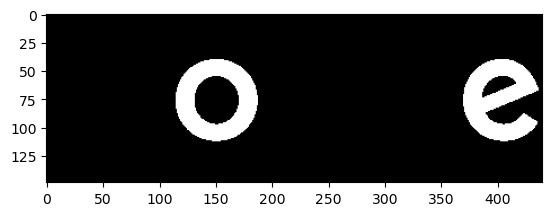

In [250]:
retval, imgGoogleMask2 = cv2.threshold(imgGoogleGray, 100, 255, cv2.THRESH_BINARY)
imgGoogleMaskInv2 = cv2.bitwise_not(imgGoogleMask2)
plt.imshow(imgGoogleMaskInv2, cmap = 'gray')

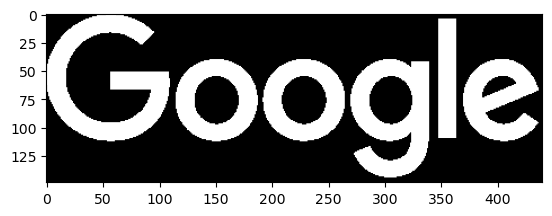

In [252]:
retval, imgGoogleMask0 = cv2.threshold(imgGoogleGray, 200, 255, cv2.THRESH_BINARY)
imgGoogleMaskInv0 = cv2.bitwise_not(imgGoogleMask0)
plt.imshow(imgGoogleMaskInv0, cmap = 'gray')

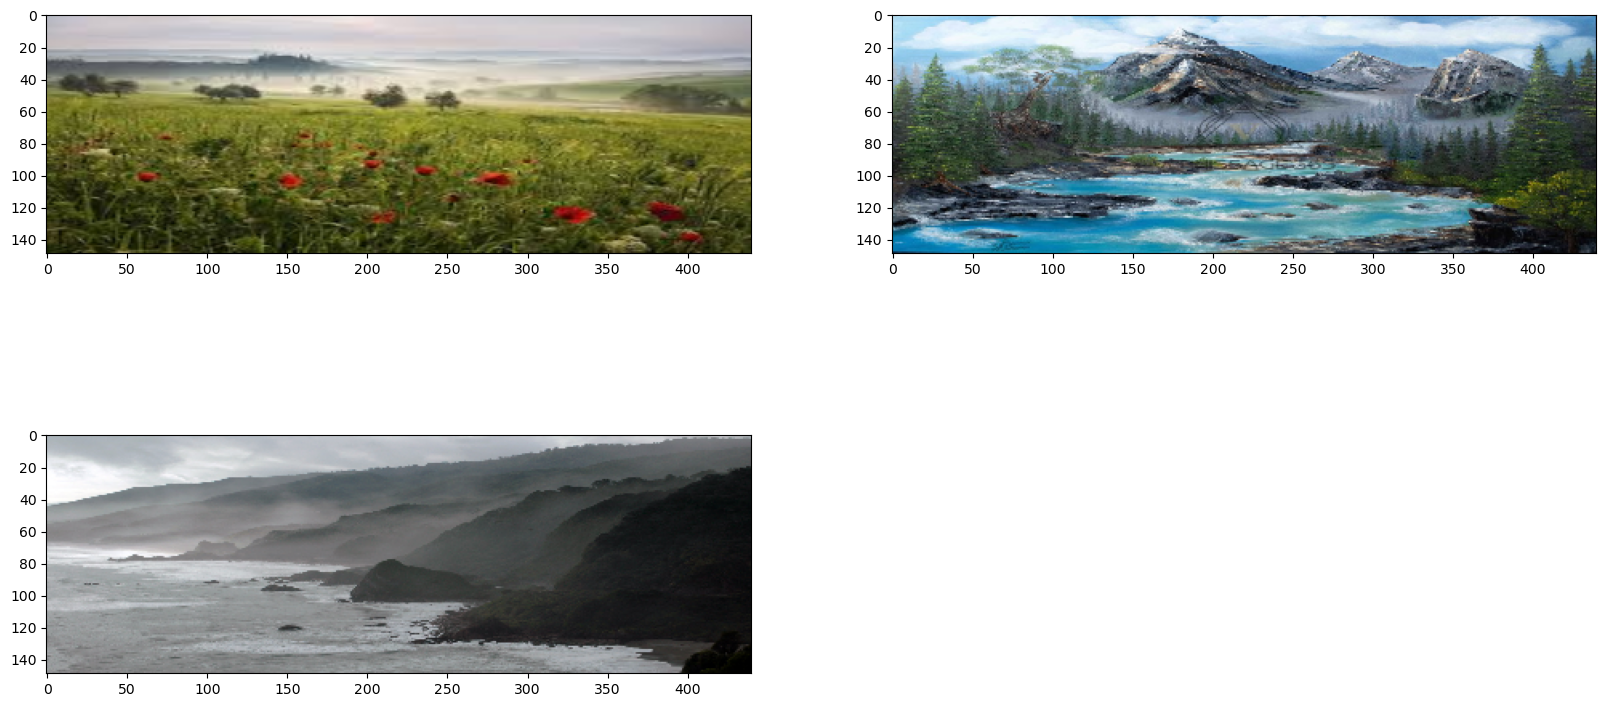

In [308]:
imgpicture1 = cv2.imread("images.jpeg")
imgpicture1Rgb = cv2.cvtColor(imgpicture1, cv2.COLOR_BGR2RGB)
dim = (imgGoogleRgb.shape[1], imgGoogleRgb.shape[0])
imgpicture1Rgb = cv2.resize(imgpicture1Rgb, dim)
plt.figure(figsize=[20,10])
plt.subplot(221); plt.imshow(imgpicture1Rgb)
imgpicture2 = cv2.imread("ZpSBqqoSkTT7_800x600_AybP2us9.jpg")
imgpicture2Rgb = cv2.cvtColor(imgpicture2, cv2.COLOR_BGR2RGB)
imgpicture2Rgb = cv2.resize(imgpicture2Rgb, dim)
plt.subplot(222); plt.imshow(imgpicture2Rgb)

imgpicture3 = cv2.imread("New_Zealand_Coast.jpg")
imgpicture3Rgb = cv2.cvtColor(imgpicture3, cv2.COLOR_BGR2RGB)
imgpicture3Rgb = cv2.resize(imgpicture3Rgb, dim)
plt.subplot(223); plt.imshow(imgpicture3Rgb)


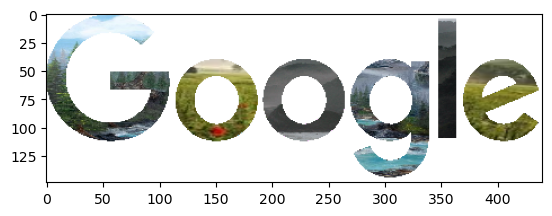

In [316]:
imgBgrColor = cv2.bitwise_and(imgpicture1Rgb, imgpicture1Rgb, mask = imgGoogleMaskInv2)
imgBgrColor = cv2.bitwise_or(imgBgrColor, cv2.bitwise_and(imgpicture2Rgb, imgpicture2Rgb, mask = cv2.bitwise_xor(imgGoogleMaskInv2,imgGoogleMaskInv1)))
imgBgrColor = cv2.bitwise_or(imgBgrColor, cv2.bitwise_and(imgpicture3Rgb, imgpicture3Rgb, mask = cv2.bitwise_xor(imgGoogleMaskInv0,imgGoogleMaskInv1)))
imgBgrColor2 = cv2.bitwise_or(imgGoogleRgb, imgGoogleRgb, mask = cv2.bitwise_not(imgGoogleMaskInv0))
imgBgrColor = cv2.bitwise_or(imgBgrColor, imgBgrColor2)
plt.imshow(imgBgrColor)